In [3]:
import joblib
import numpy as np
import pandas as pd
import umap

import onnx
from onnx import helper, numpy_helper

import hdbscan
from sklearn.decomposition import PCA
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [4]:
# 1. Caminhos dos arquivos
caminho_modelo = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\model\production\melhor_modelo_producao.onnx"
caminho_mappings = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\model\production\mappings_v1.joblib"

print("Carregando modelo ONNX e mapeamentos...")
model_onnx = onnx.load(caminho_modelo)
mappings = joblib.load(caminho_mappings)

print("Chaves encontradas no mappings:", mappings.keys())

# 2. Função ajustada para buscar pelo nome exato do tensor
def processar_e_salvar_embeddings(nome_tensor_alvo, chave_mapping, nome_saida):
    print(f"\n--- Processando Embeddings de: {nome_saida} ---")
    
    matriz_pesos = None
    for init in model_onnx.graph.initializer:
        if init.name == nome_tensor_alvo:
            matriz_pesos = numpy_helper.to_array(init)
            print(f"Tensor encontrado: {init.name} | Shape: {matriz_pesos.shape}")
            break
            
    if matriz_pesos is None:
        print(f"⚠️ Tensor '{nome_tensor_alvo}' não foi encontrado no ONNX.")
        return

    # Pega o dicionário do joblib
    vocab_dict = mappings.get(chave_mapping)
    if vocab_dict is None:
        print(f"⚠️ Chave '{chave_mapping}' não encontrada no arquivo joblib.")
        return

    # Inverte o dicionário para mapear ID -> Nome do Material
    id_para_nome = {v: k for k, v in vocab_dict.items()}
    
    nomes_materiais = []
    for i in range(len(matriz_pesos)):
        nomes_materiais.append(id_para_nome.get(i, f"Desconhecido_{i}"))

    # Cria o DataFrame e salva
    df_embeddings = pd.DataFrame(matriz_pesos)
    df_embeddings.insert(0, 'material', nomes_materiais)
    
    nome_arquivo = f"embeddings_{nome_saida}.csv"
    df_embeddings.to_csv(nome_arquivo, index=False)
    print(f"✅ Salvo com sucesso em: {nome_arquivo}")

# 3. Executando com os nomes exatos descobertos
processar_e_salvar_embeddings('emb_base.weight', 'material_base', 'base')
processar_e_salvar_embeddings('emb_add.weight', 'material_adicao', 'adicao')

Carregando modelo ONNX e mapeamentos...
Chaves encontradas no mappings: dict_keys(['material_base', 'material_adicao', 'vocab_sizes'])

--- Processando Embeddings de: base ---
Tensor encontrado: emb_base.weight | Shape: (72, 16)
✅ Salvo com sucesso em: embeddings_base.csv

--- Processando Embeddings de: adicao ---
Tensor encontrado: emb_add.weight | Shape: (73, 16)
✅ Salvo com sucesso em: embeddings_adicao.csv


In [5]:
df_base = pd.read_csv(r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\embedding\embeddings_base.csv")
df_adicao = pd.read_csv(r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\embedding\embeddings_adicao.csv")

df_b = df_base.select_dtypes(include=["number"])
df_a = df_adicao.select_dtypes(include=["number"])

emb_cols = [c for c in df_b.columns if c not in ("material", "tipo")]
X = df_b[emb_cols].values
Y = df_a[emb_cols].values
 
print(f"Total de materiais: {X.shape[0]}, dimensões do embedding: {X.shape[1]}")

Total de materiais: 72, dimensões do embedding: 16


In [6]:

pca = PCA(n_components=2, random_state=42)
Y_pca = pca.fit_transform(df_a)
print(f"Variância explicada pelo PCA (3 comp.): {pca.explained_variance_ratio_.sum():.2%}")
X_pca = pca.fit_transform(df_b)
print(f"Variância explicada pelo PCA (3 comp.): {pca.explained_variance_ratio_.sum():.2%}")

Variância explicada pelo PCA (3 comp.): 22.57%
Variância explicada pelo PCA (3 comp.): 23.02%


In [7]:

perplexity = min(30, max(5, X.shape[0] // 4))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto",
)
Y_tsne = tsne.fit_transform(df_a)
print(f"KL divergence final: {tsne.kl_divergence_:.4f}")
X_tsne = tsne.fit_transform(df_b)
print(f"KL divergence final: {tsne.kl_divergence_:.4f}")
from sklearn.manifold import trustworthiness
score = trustworthiness(X, X_tsne, n_neighbors=5)
print(f"Trustworthiness: {score:.4f}")
score2 = trustworthiness(Y, Y_tsne, n_neighbors=5)
print(f"Trustworthiness: {score2:.4f}")

KL divergence final: 0.7652
KL divergence final: 0.7101
Trustworthiness: 0.8604
Trustworthiness: 0.8446


In [8]:

n_neighbors = min(15, max(2, X.shape[0] - 1))
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=0.1,
    random_state=42,
)
X_umapb = reducer.fit_transform(df_b)
X_umapa = reducer.fit_transform(df_a)

c:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:

score = trustworthiness(X, X_umapb, n_neighbors=5)
print(f"Trustworthiness: {score:.4f}")
score2 = trustworthiness(Y, X_umapa, n_neighbors=5)
print(f"Trustworthiness: {score2:.4f}")

Trustworthiness: 0.8444
Trustworthiness: 0.7842


C:\Users\Workstation\AppData\Local\Temp\ipykernel_26808\2390492696.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(projection[:, 0], projection[:, 1],  cmap='tab20', alpha=0.7)


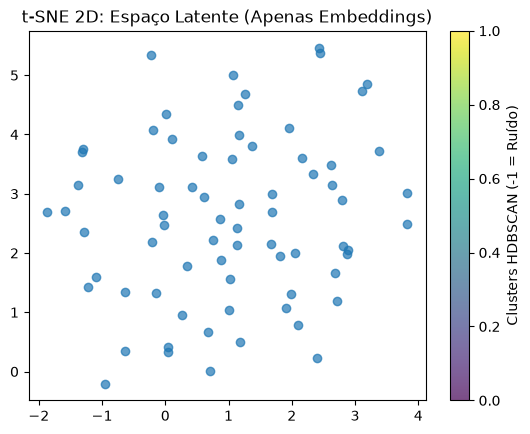

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
projection = TSNE(n_components=2, random_state=42).fit_transform(df_b)

# 3. Plota o gráfico usando os rótulos do HDBSCAN para colorir (parâmetro 'c')
# O cmap='tab20' ajuda a diferenciar bem as cores dos diferentes materiais/clusters
scatter = plt.scatter(projection[:, 0], projection[:, 1],  cmap='tab20', alpha=0.7)

# Adiciona uma legenda lateral para saber quem é qual cluster
plt.colorbar(scatter, label='Clusters HDBSCAN (-1 = Ruído)')
plt.title('t-SNE 2D: Espaço Latente (Apenas Embeddings)')
plt.show()

c:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


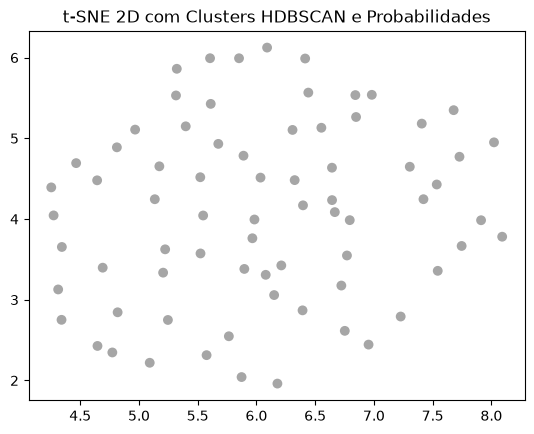

In [11]:
import seaborn as sns
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4, 
    min_samples=3, 
    cluster_selection_method='leaf', # Voltamos ao agrupamento por massa
    cluster_selection_epsilon=0.5
).fit(X)
projection = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1, random_state=42
).fit_transform(X)

# 4. Configurar as cores baseadas nas probabilidades geradas pelo HDBSCAN
color_palette = sns.color_palette('Paired', 12)
cluster_colors = [color_palette[x] if x >= 0 else (0.5, 0.5, 0.5) for x in clusterer.labels_]
cluster_member_colors = [sns.desaturate(x, p) for x, p in zip(cluster_colors, clusterer.probabilities_)]

# 5. Gerar o gráfico final (usando 'c=cluster_member_colors')
plt.scatter(projection[:, 0], projection[:, 1], s=50, linewidth=0, c=cluster_member_colors, alpha=0.7)
plt.title('t-SNE 2D com Clusters HDBSCAN e Probabilidades')
plt.show()

c:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


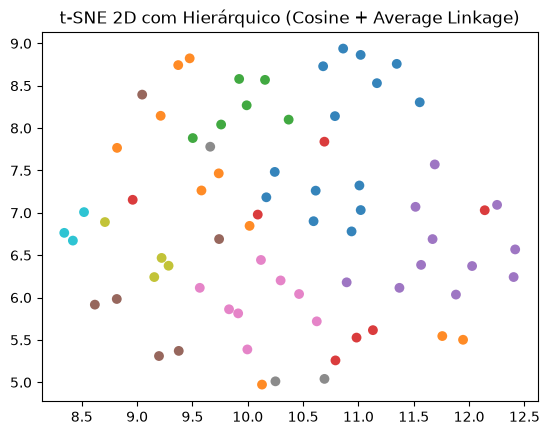

In [12]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Correção: Com metric='cosine', use linkage='average' ou 'complete'
clusterer = AgglomerativeClustering(n_clusters=10, metric='cosine', linkage='average')

# 2. Treinar o algoritmo com os seus embeddings originais de 8D
rotulos_hierarquico = clusterer.fit_predict(X)

# 3. Gerar a projeção t-SNE 
projection = umap.UMAP(
    n_components=2, n_neighbors=12, min_dist=0.1, random_state=42
).fit_transform(X)

# 4. Configurar as cores (a paleta 'tab10' suporta exatamente até 10 cores)
color_palette = sns.color_palette('tab10', 10)
cluster_colors = [color_palette[x] for x in rotulos_hierarquico]

# 5. Plota o gráfico final
plt.scatter(projection[:, 0], projection[:, 1], s=50, linewidth=0, c=cluster_colors, alpha=0.9)
plt.title('t-SNE 2D com Hierárquico (Cosine + Average Linkage)')
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering

print("1. A carregar embeddings e a executar a clusterização...")
caminho_embeddings = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\embedding\embeddings_base.csv"
df_base = pd.read_csv(caminho_embeddings)

# Isolar apenas as 8 dimensões de embedding
emb_cols = [c for c in df_base.columns if c not in ("material", "tipo")]
X = df_base[emb_cols].values

# Aplicar a Clusterização Hierárquica (Cosine + Average Linkage, 5 clusters)
clusterer = AgglomerativeClustering(n_clusters=12, metric='cosine', linkage='average')
df_base['Cluster'] = clusterer.fit_predict(X)

print("2. A carregar o ficheiro de metadados...")
caminho_dados = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\processed\dados_preprocessados.csv"
df_metadados = pd.read_csv(caminho_dados)

# 3. Consolidar o df_metadados para ter apenas 1 linha por material_base
# (Pegamos o primeiro valor encontrado para as caraterísticas fixas e juntamos os processos)
print("3. A consolidar os passes por material para evitar duplicação...")
df_metadados_unico = df_metadados.groupby('material_base').agg({
    'pnumber': 'first',
    'espessura': 'first',
    'pre_aquecimento': 'first',
    'temperatura_interpasse': 'first',
    'posicao_peca': 'first',
    'processo': lambda x: ' / '.join(x.dropna().unique()),         # Junta os processos usados (ex: TIG / MIG)
    'material_adicao': lambda x: ' / '.join(x.dropna().unique()) # Junta os consumíveis usados
}).reset_index()

# 4. Fazer o merge do cluster com a base limpa de 72 linhas
df_completo = pd.merge(
    df_base[['material', 'Cluster']],
    df_metadados_unico,
    left_on='material',
    right_on='material_base',
    how='inner'
)

# Organizar as colunas finais e ordenar por cluster
colunas_finais = [
    'material', 'Cluster', 'pnumber', 'espessura', 
    'pre_aquecimento', 'temperatura_interpasse', 
    'posicao_peca', 'processo', 'material_adicao'
]

df_validacao_limpa = df_completo[[c for c in colunas_finais if c in df_completo.columns]].sort_values(by='Cluster')

print(f"Total de linhas finais consolidadas: {len(df_validacao_limpa)} (Deve ser igual ao número de materiais)")

print("5. A exportar para Excel (ou CSV)...")
# Se já tiver o openpyxl instalado, use to_excel. Se preferir CSV para evitar erros, use to_csv.
caminho_excel = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\validacao_clusters_limpa.xlsx"
try:
    df_validacao_limpa.to_excel(caminho_excel, index=False)
    print(f"✅ Ficheiro Excel guardado com sucesso em:\n{caminho_excel}")
except ModuleNotFoundError:
    caminho_csv = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\validacao_clusters_limpa.csv"
    df_validacao_limpa.to_csv(caminho_csv, index=False, encoding='utf-8-sig')
    print(f"⚠️ 'openpyxl' não encontrado. Ficheiro guardado como CSV em:\n{caminho_csv}")

display(df_validacao_limpa.head(10))

1. A carregar embeddings e a executar a clusterização...
2. A carregar o ficheiro de metadados...
3. A consolidar os passes por material para evitar duplicação...
Total de linhas finais consolidadas: 67 (Deve ser igual ao número de materiais)
5. A exportar para Excel (ou CSV)...
✅ Ficheiro Excel guardado com sucesso em:
C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\validacao_clusters_limpa.xlsx


,material,Cluster,pnumber,espessura,pre_aquecimento,temperatura_interpasse,posicao_peca,processo,material_adicao
0,API5LX65QPSL2,0,1,14.00,22.0,223.0,6G,TIG / ER / FCAW,ER80SNI1 / E8018C3H4R / E81T1K2C
2,B4441N06625,0,43,2.77,23.0,85.0,6G,TIG,ERNICRMO3
12,A312TP316316L,0,8,18.20,15.0,150.0,6G,TIG / ER,ER316L / E316L17
9,A335P9,0,5B,11.00,260.0,300.0,2G,TIG / ER,ER80SB8 / ER80SB6 / ERNICRMO3 / ER505 / E8018B8
24,A131EH36,0,1,26.00,23.0,235.0,3G,FCAW,E71T1CJ / E71T1 / E81T1NI1
20,A312,0,8,24.00,20.0,150.0,6G,TIG / FCAW,ER316L / E316LT11
42,B564N06625,0,43,23.01,18.0,100.0,6G,TIG,ERNICRMO3
39,SB677SN08904,0,45,16.30,20.0,100.0,5G,TIG / ER,WZ20255CUNL / E20255CUNLB22
62,A335P22,0,5A,6.00,250.0,350.0,2G,TIG,ER90SB3
45,A51670,0,1,31.00,125.0,250.0,3G,TIG / FCAW / MIG / ER,ER80SNI2 / E71T1C / ER70S6 / E70181


material,Desconhecido_0,API5LX65QPSL2,A240TP304,B4441N06625,A312TP316L,A240TP439,A790S32750,A38711CL1,API5LX52,API5LB,...,A131,A358,SB407SN08811,B668,A131AH36,A335P22,B575S10276,SB127,A790S32760,B705SN06625
material,,,,,,,,,,,,,,,,,,,,,
Desconhecido_0,0.000000,0.780241,0.591095,0.783900,1.190422,0.808441,0.667242,1.130591,1.318422,1.138465,...,1.083567,1.089254,1.579298,0.915471,0.755145,1.386728,0.997072,1.363792,0.981672,1.419158
API5LX65QPSL2,0.780241,0.000000,0.775830,0.236415,0.973062,1.198168,0.505123,1.257452,1.387799,1.052571,...,0.622058,1.318066,1.207318,0.857129,0.749147,0.549904,1.056741,1.163136,1.197921,0.925922
A240TP304,0.591095,0.775830,0.000000,0.714505,1.388015,0.890419,0.710768,0.971330,1.000480,1.153034,...,1.088645,1.277426,0.981881,0.835329,1.208230,1.049792,0.883392,0.858841,0.917445,1.484680
B4441N06625,0.783900,0.236415,0.714505,0.000000,0.983723,1.286534,0.555302,1.326049,1.107773,1.186205,...,0.866557,1.228329,1.260058,0.762285,0.671097,0.569972,0.938371,1.192514,1.089137,0.750764
A312TP316L,1.190422,0.973062,1.388015,0.983723,0.000000,1.127189,1.123940,0.758231,1.045514,0.979442,...,0.503832,1.365846,1.227658,0.660977,0.948496,0.985416,0.888117,0.996558,1.226884,0.412490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A335P22,1.386728,0.549904,1.049792,0.569972,0.985416,1.174832,1.077356,1.055655,1.169165,1.168057,...,0.455476,1.026304,0.797594,0.961387,1.018708,0.000000,1.362737,1.048627,0.897684,0.761059
B575S10276,0.997072,1.056741,0.883392,0.938371,0.888117,0.878425,0.672577,0.634951,0.585866,1.153215,...,1.519264,1.316413,0.912394,0.636752,1.116867,1.362737,0.000000,0.973461,1.278075,0.656719
SB127,1.363792,1.163136,0.858841,1.192514,0.996558,1.099042,1.060856,0.679618,0.714306,0.821036,...,1.036848,1.059031,0.855600,0.796555,1.009965,1.048627,0.973461,0.000000,1.002111,1.010031


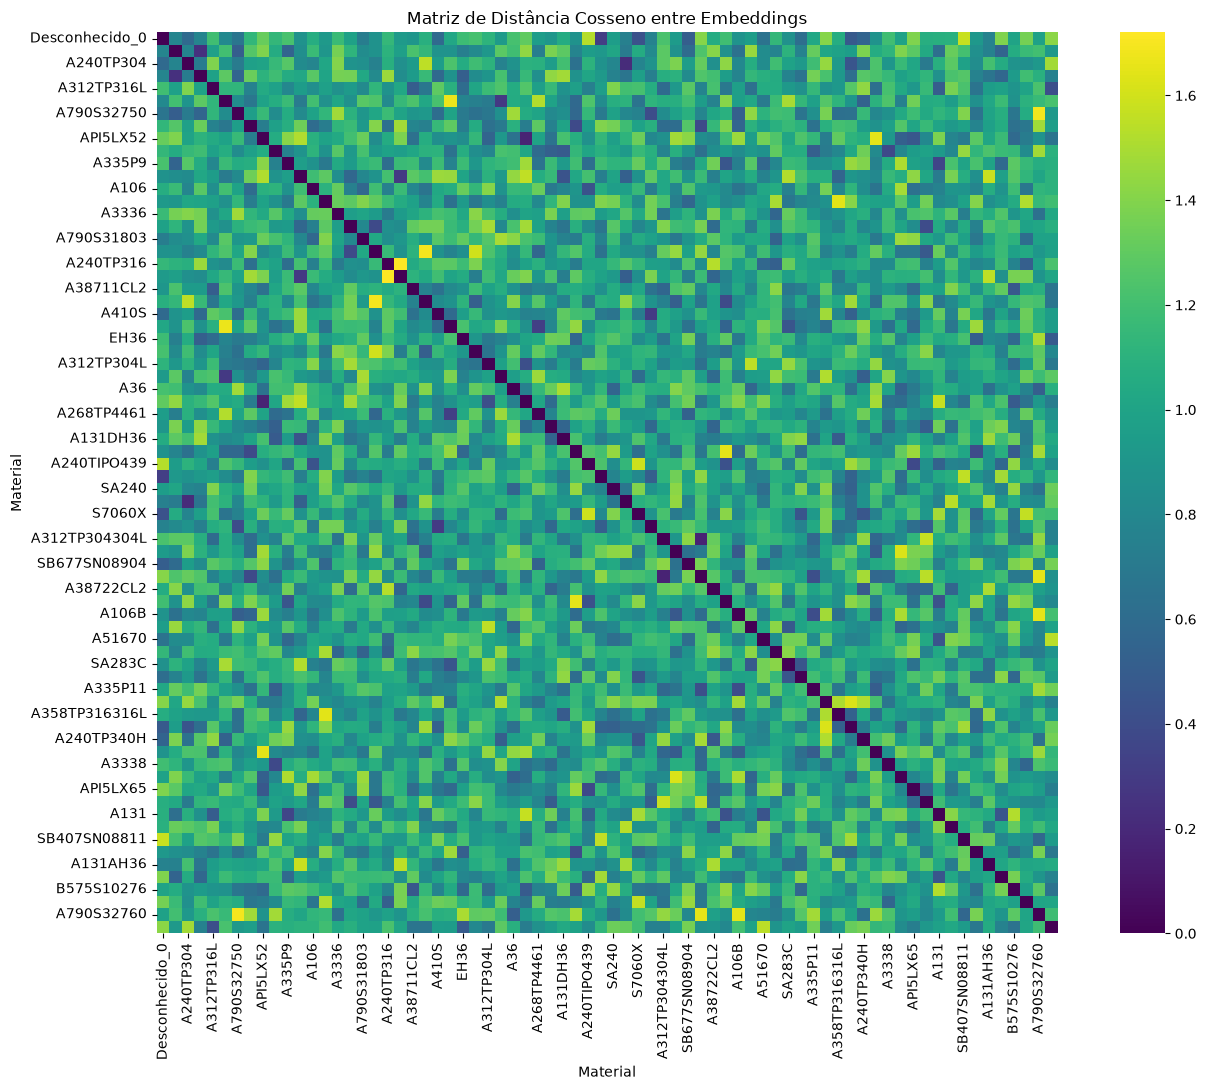

In [14]:
from sklearn.metrics import pairwise_distances

# Calcula a matriz de distância entre os embeddings
matriz_distancias = pairwise_distances(df_b, metric="cosine")

# DataFrame com os materiais como índices e colunas
df_distancias = pd.DataFrame(
    matriz_distancias,
    index=df_base["material"],
    columns=df_base["material"]
)

display(df_distancias)

# Visualização da matriz
plt.figure(figsize=(14, 11))
sns.heatmap(df_distancias, cmap="viridis", square=True)
plt.title("Matriz de Distância Cosseno entre Embeddings")
plt.xlabel("Material")
plt.ylabel("Material")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Opcional: salvar em CSV
df_distancias.to_csv("matriz_distancias_embeddings.csv")

In [18]:
import pandas as pd
import numpy as np

df_distancias = pd.read_csv("C:\\Users\\Workstation\\Documents\\GitHub\\welding-optuna-pytorch\\notebook\\matriz_distancias_embeddings.csv", index_col=0)

# Considera apenas a metade superior da matriz e ignora a diagonal
pares_proximos = (
    df_distancias.where(
        np.triu(np.ones(df_distancias.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()  # transforma a Series (com MultiIndex) em DataFrame de 3 colunas
)

pares_proximos.columns = ["material_1", "material_2", "distancia_euclidiana"]

top_10_materiais = pares_proximos.sort_values(
    by="distancia_euclidiana"
).head(10)

print(top_10_materiais)

          material_1   material_2  distancia_euclidiana
2923   A312TP304304L   A928S31803              0.161598
605         API5LX52    A351CT15C              0.162926
181        A240TP304        SA312              0.211869
75     API5LX65QPSL2  B4441N06625              0.236415
811           SA285C   A240TP310S              0.284067
387        A240TP439   A487CA6NMA              0.285526
1623           A410S        A285C              0.300282
35    Desconhecido_0    A240TP410              0.310950
1686       A312TP304   A268TP4461              0.319257
782           A335P9         A131              0.350512
